In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../utaut2_dataset/new_result.xlsx')

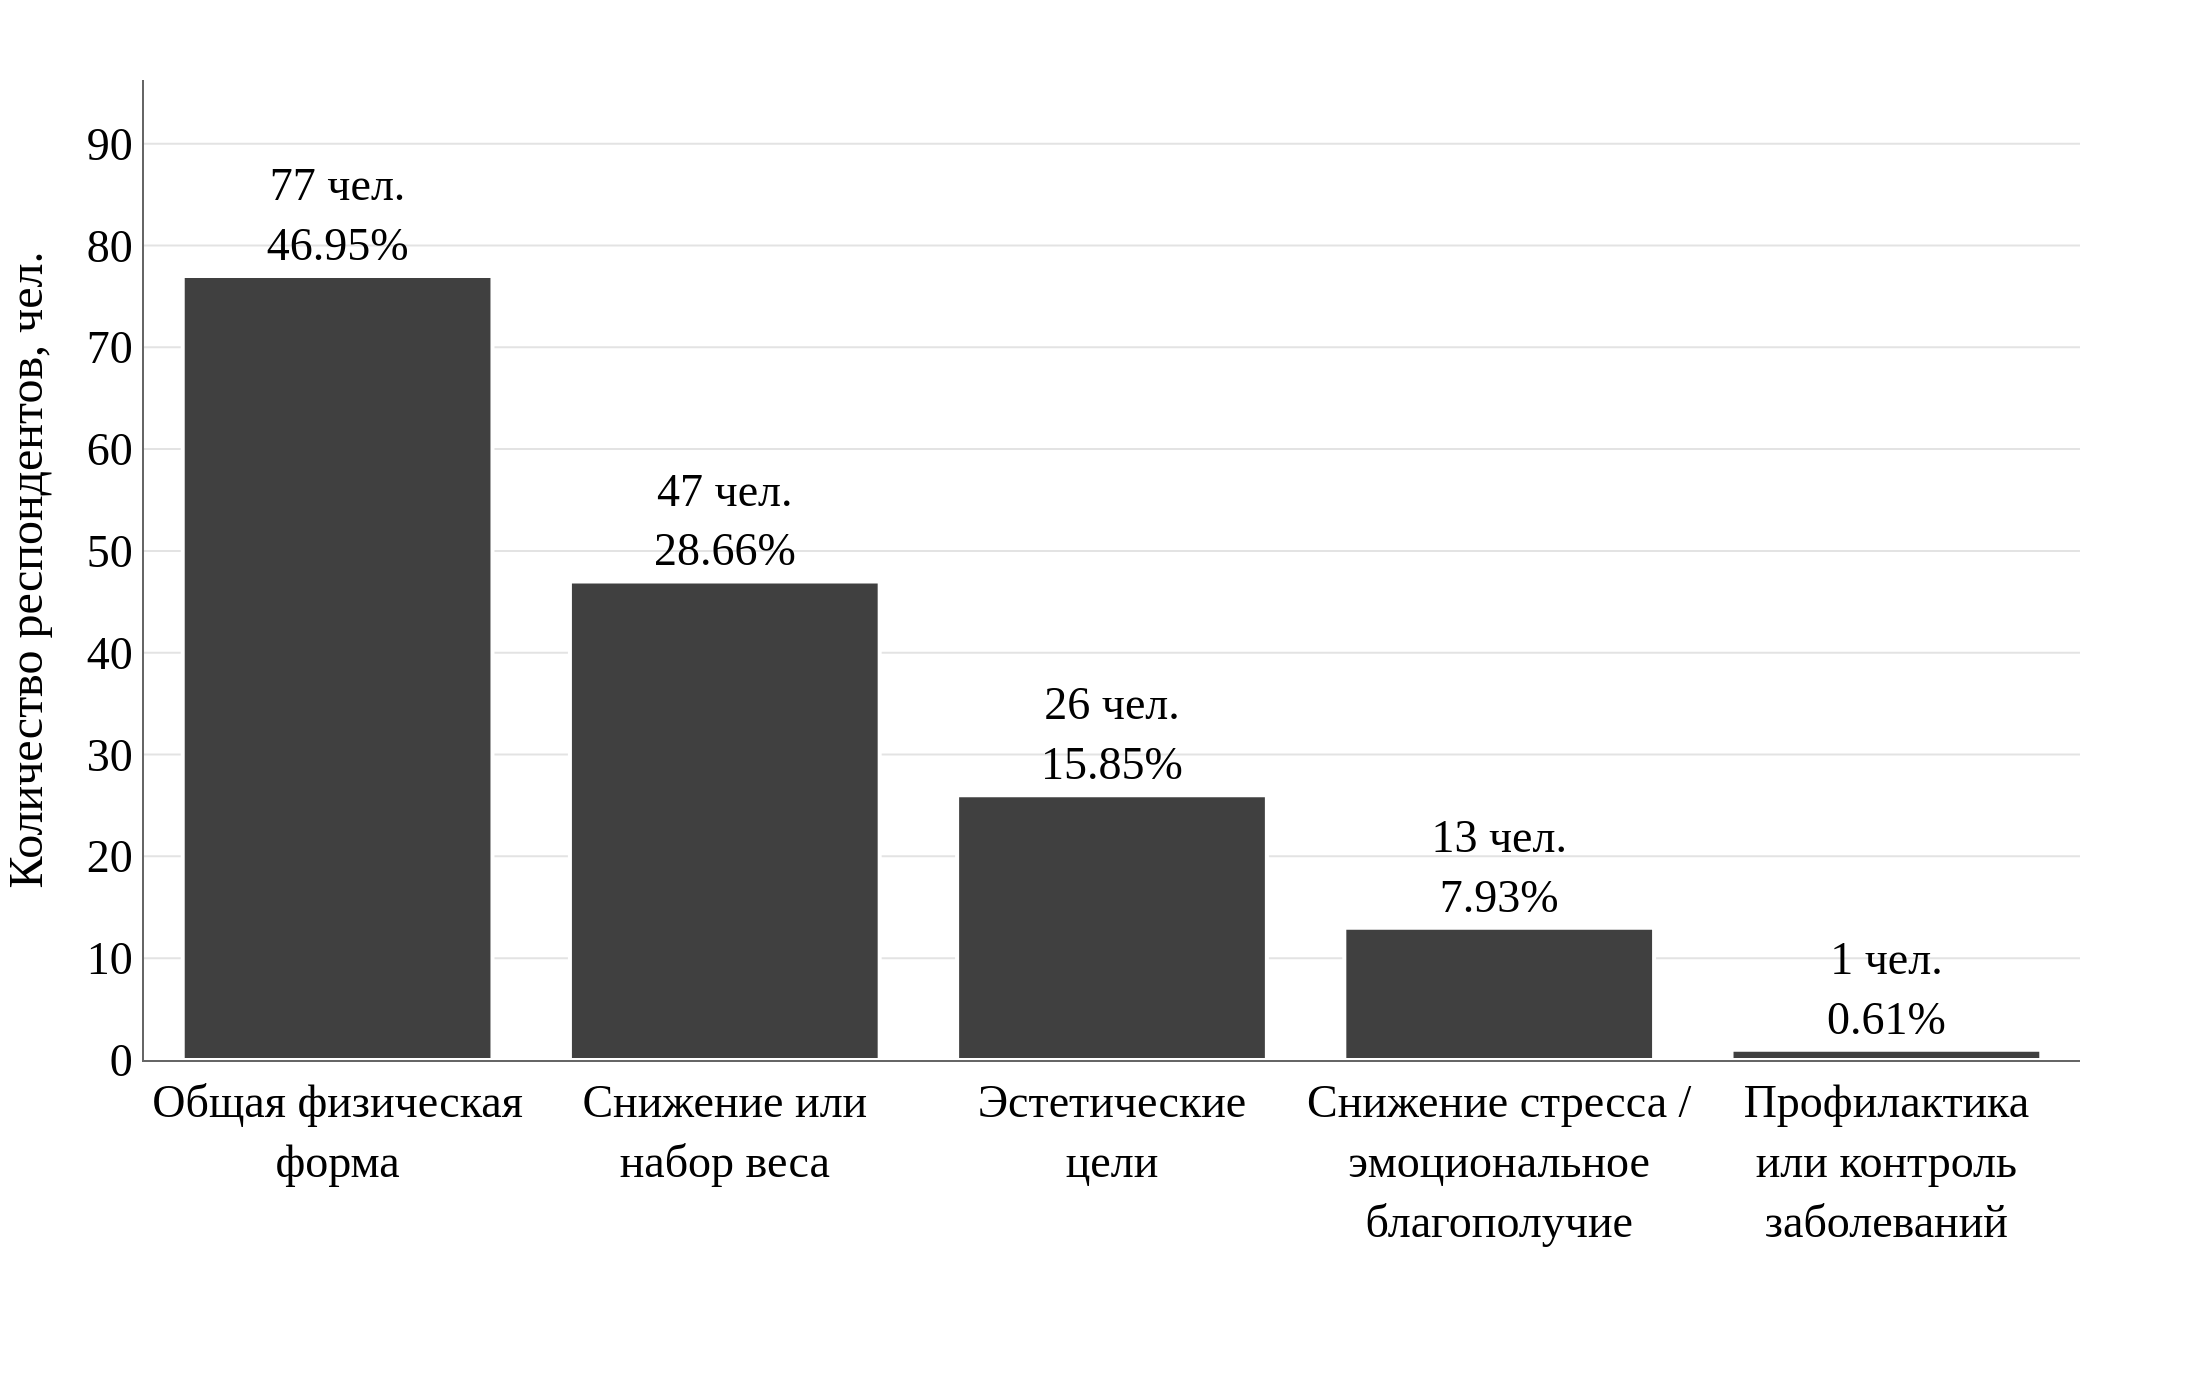

In [2]:
goal_col = 'What is your main goal for engaging in physical activity?'

goal_order = [
    'Improving overall fitness (strength, endurance, flexibility)',
    'Losing or gaining weight',
    'Aesthetic goals (appearance)',
    'Reducing stress / improving emotional well-being',
    'Disease prevention or management'
]

goal_ru = {
    'Improving overall fitness (strength, endurance, flexibility)': 'Общая физическая<br>форма',
    'Losing or gaining weight': 'Снижение или<br>набор веса',
    'Aesthetic goals (appearance)': 'Эстетические<br>цели',
    'Reducing stress / improving emotional well-being': 'Снижение стресса /<br>эмоциональное<br>благополучие',
    'Disease prevention or management': 'Профилактика<br>или контроль<br>заболеваний'
}

goal_data = df[df[goal_col].notna()].copy()
goal_counts = goal_data[goal_col].value_counts().reindex(goal_order).fillna(0).astype(int)
goal_pct = (goal_counts / goal_counts.sum() * 100).round(2)

fig = go.Figure(data=[go.Bar(
    x=[goal_ru[x] for x in goal_counts.index],
    y=goal_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(goal_counts.values, goal_pct.values)],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, goal_counts.max() * 1.25]
    ),
    margin=dict(l=60, r=60, t=40, b=170),
    width=1100,
    height=700
)

fig.show()


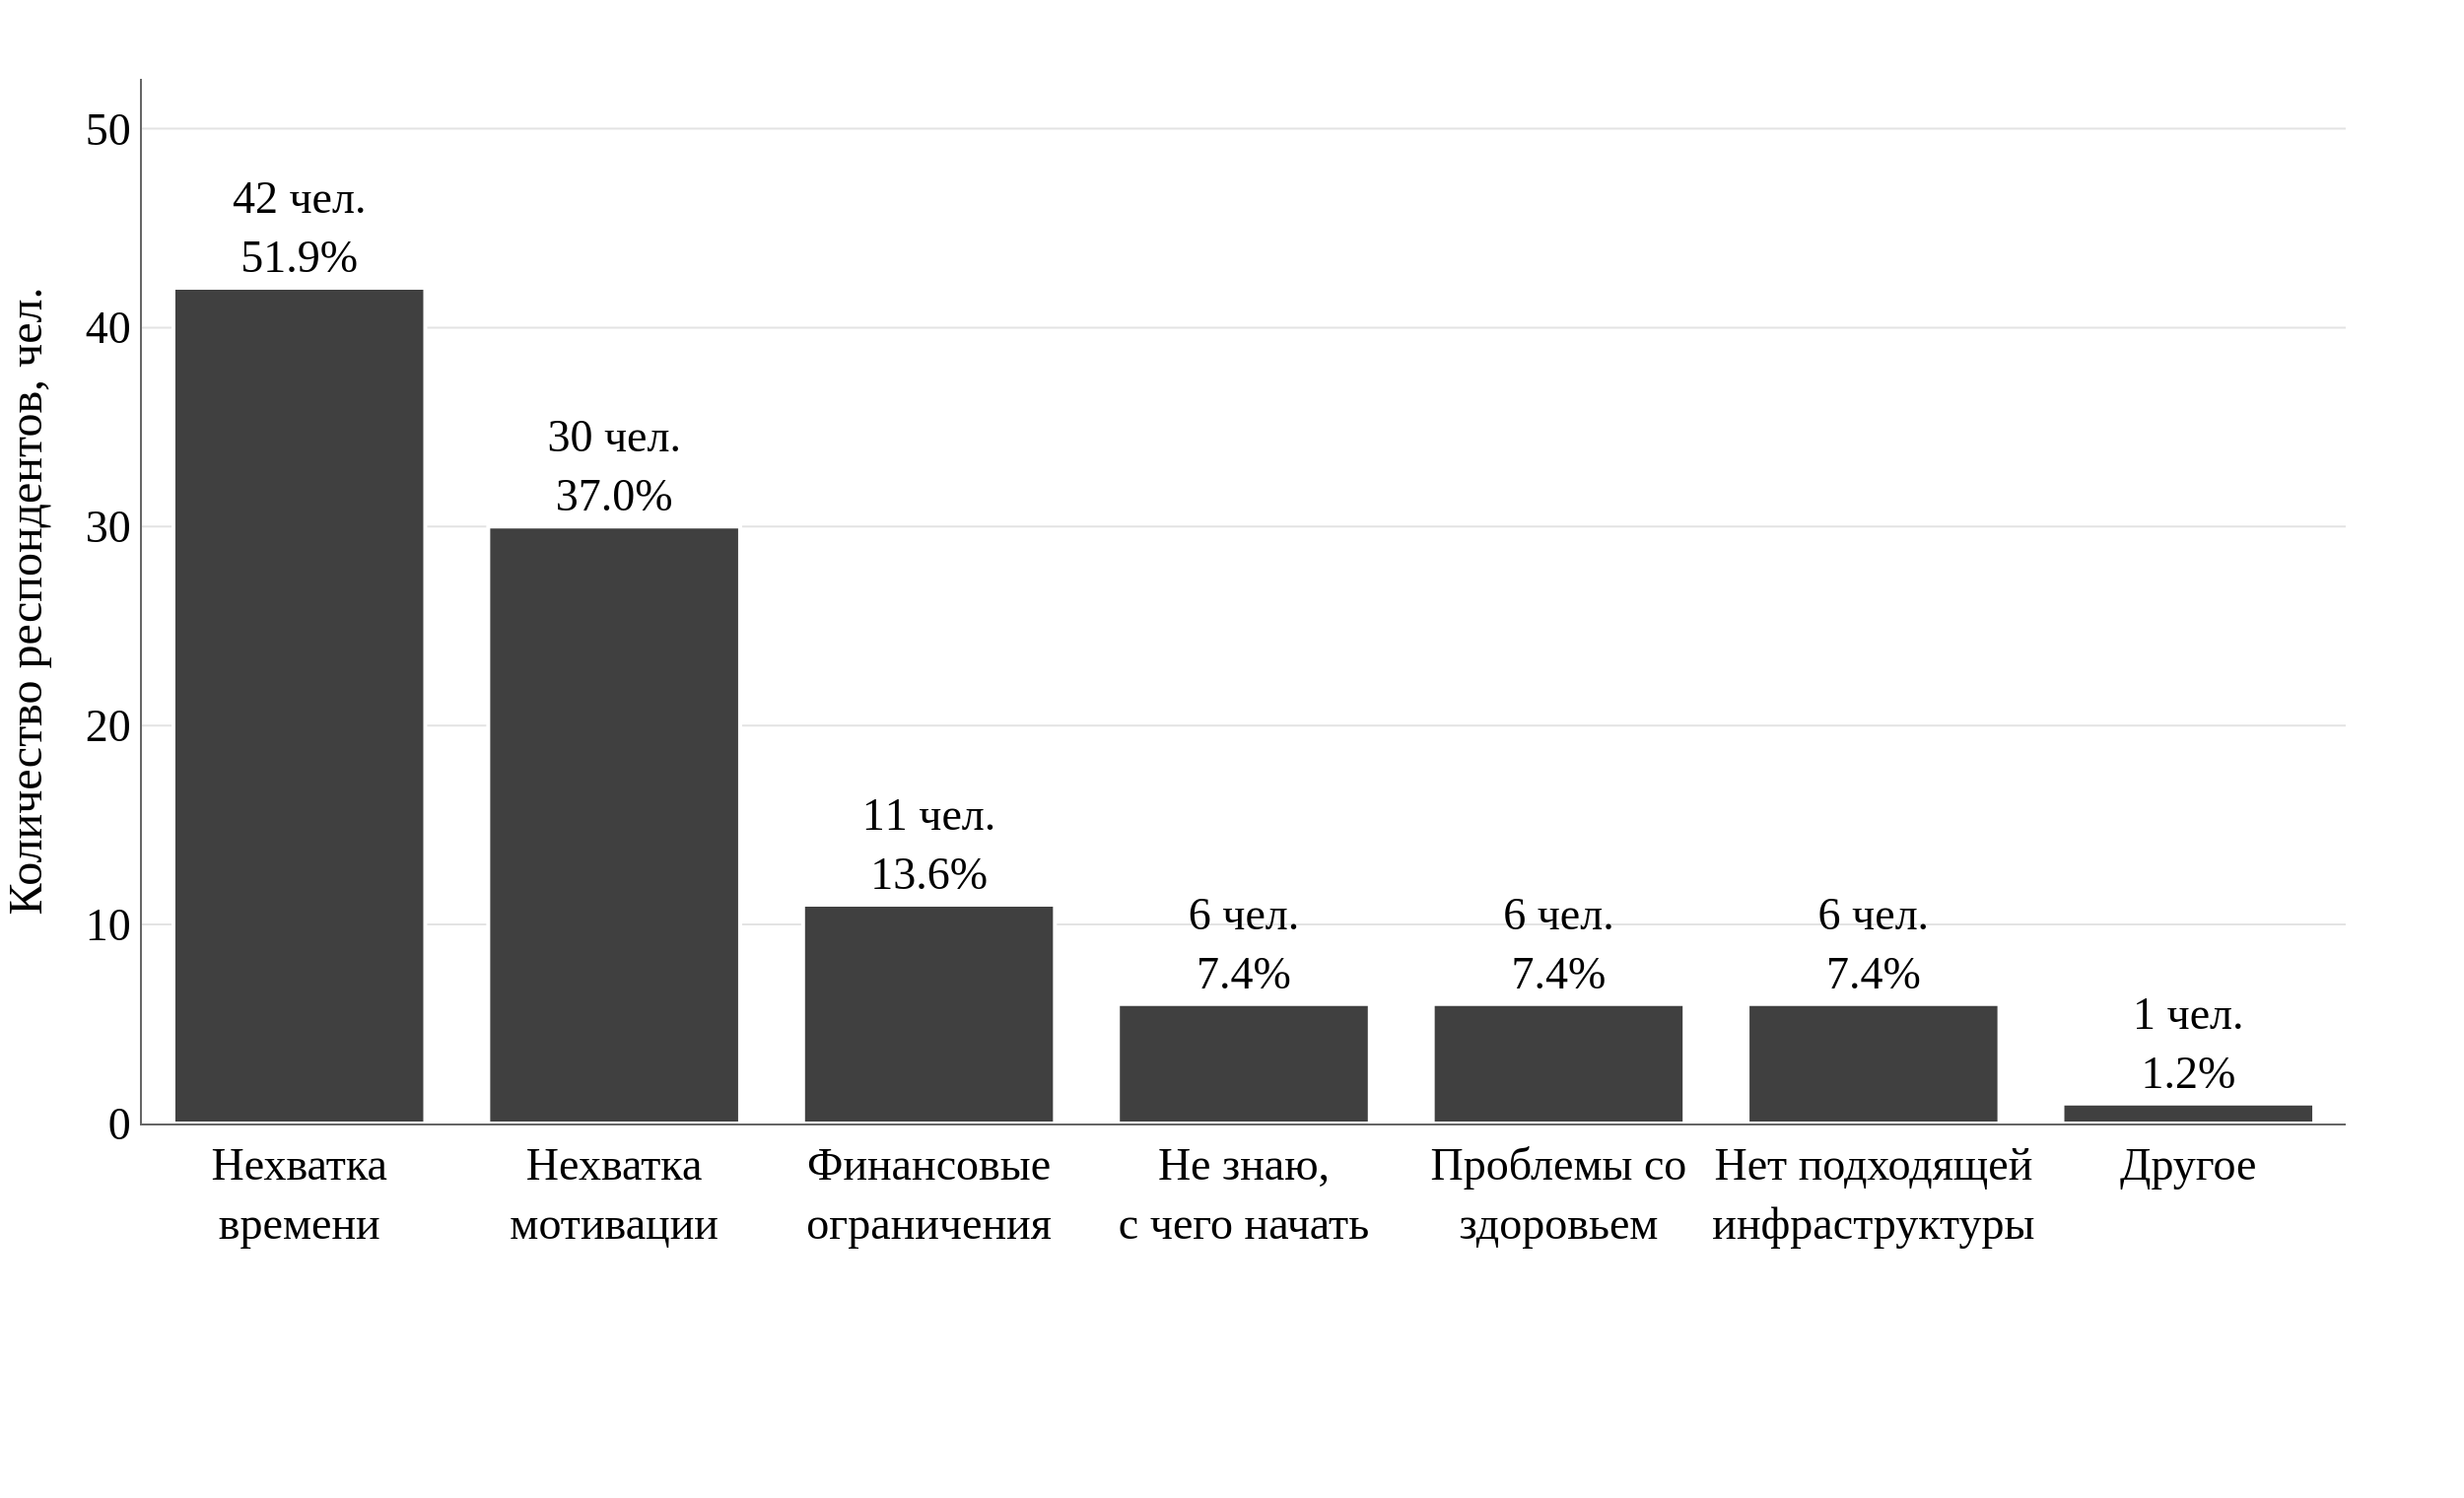

In [3]:
bar_col = 'If you exercise less regularly than you would like, what is holding you back?\n If you are satisfied with your current frequency - skip this question.'

bar_order = [
    'Lack of time',
    'Lack of motivation',
    'Financial constraints (expensive gym, trainer)',
    'Do not know where or how to start',
    'Health issues / injuries',
    'No suitable facilities nearby',
    'Other'
]

bar_ru = {
    'Lack of time': 'Нехватка<br>времени',
    'Lack of motivation': 'Нехватка<br>мотивации',
    'Financial constraints (expensive gym, trainer)': 'Финансовые<br>ограничения',
    'Do not know where or how to start': 'Не знаю,<br>с чего начать',
    'Health issues / injuries': 'Проблемы со<br>здоровьем',
    'No suitable facilities nearby': 'Нет подходящей<br>инфраструктуры',
    'Other': 'Другое'
}

bar_data = df[df[bar_col].notna()].copy()

bar_counts = pd.Series({
    opt: bar_data[bar_col].fillna('').str.contains(opt, regex=False).sum()
    for opt in bar_order
})

bar_counts = bar_counts.reindex(bar_order).fillna(0).astype(int)
bar_pct = (bar_counts / len(bar_data) * 100).round(1)

fig = go.Figure(data=[go.Bar(
    x=[bar_ru[x] for x in bar_counts.index],
    y=bar_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(bar_counts.values, bar_pct.values)],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, bar_counts.max() * 1.25]
    ),
    margin=dict(l=60, r=60, t=40, b=190),
    width=1250,
    height=760
)

fig.show()

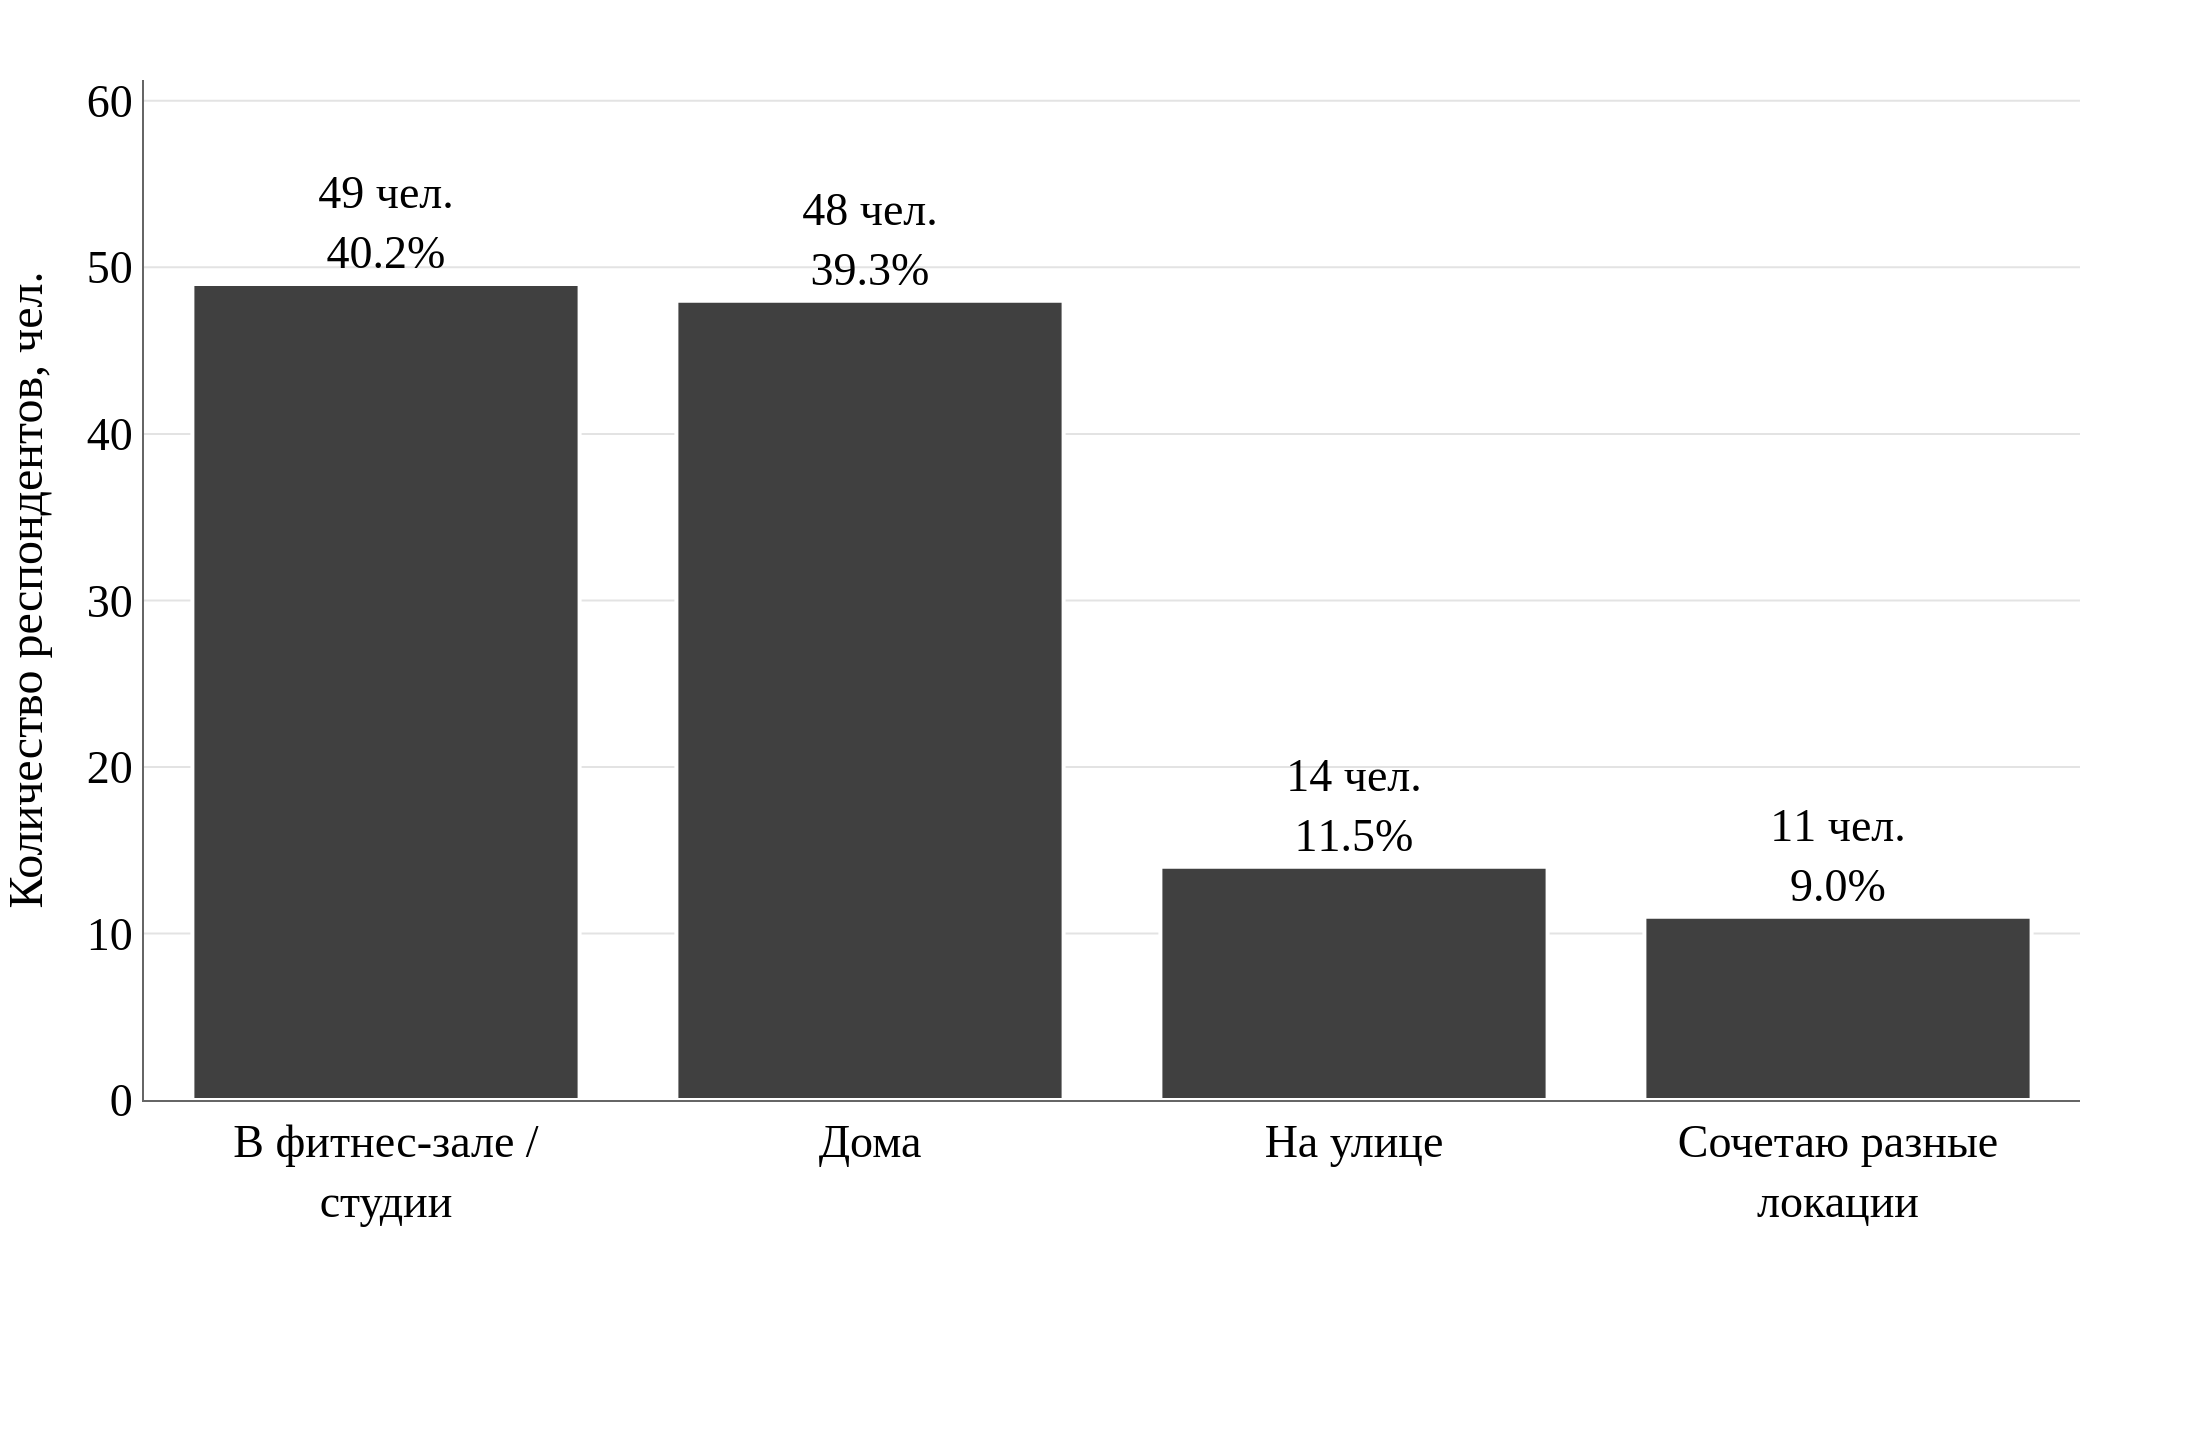

In [4]:
place_col = 'Where do you usually train?'

place_order = [
    'At a gym / fitness studio',
    'At home',
    'Outdoors (park, embankment, etc.)',
    'I combine different locations'
]

place_ru = {
    'At a gym / fitness studio': 'В фитнес-зале /<br>студии',
    'At home': 'Дома',
    'Outdoors (park, embankment, etc.)': 'На улице',
    'I combine different locations': 'Сочетаю разные<br>локации'
}

place_data = df[df[place_col].notna()].copy()
place_counts = place_data[place_col].value_counts().reindex(place_order).fillna(0).astype(int)
place_pct = (place_counts / place_counts.sum() * 100).round(1)

fig = go.Figure(data=[go.Bar(
    x=[place_ru[x] for x in place_counts.index],
    y=place_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(place_counts.values, place_pct.values)],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, place_counts.max() * 1.25]
    ),
    margin=dict(l=60, r=60, t=40, b=170),
    width=1100,
    height=720
)

fig.show()